First we ensure access to the database

In [67]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("aravind3505/dengue-detection-dataset-clinical-data")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1


In [68]:
dic = pd.read_csv("/home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1/data_dictionary.csv")

dic.head()

,Column Name,Description
0,age,Age of the patient in years
1,gender,Gender of the patient (Male/Female)
2,hemoglobin_g_dl,Hemoglobin level in grams per deciliter (g/dL)
3,wbc_count,White blood cell count (cells per microliter)
4,differential_count,Differential white blood cell count


In [69]:
import pandas as pd
df = pd.read_csv("/home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1/Dengue_diseases_dataset_modified (1).csv")
df.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


Before training machine learning models, it is important to understand how the clinical variables relate to one another and to the dengue diagnosis.

The correlation heatmap reveals that white blood cell count (WBC) and platelet count show some of the strongest relationships with the dengue label. These variables are therefore potential candidates for predictive modeling.

<Axes: >

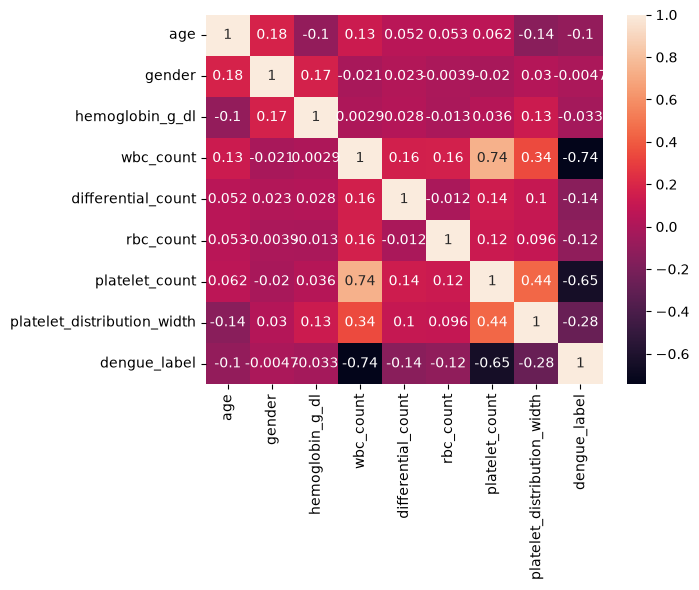

In [94]:
import seaborn as sns


sns.heatmap(df.corr(numeric_only=True),annot=True)

While correlation values provide a useful overview of feature relationships, they do not reveal how individual observations are distributed throughout the dataset.

To gain a deeper understanding of these patterns, the next step is to visualize the relationship between platelet count and white blood cell count using a scatter plot. This will help determine whether dengue-positive and dengue-negative cases exhibit distinct clinical patterns that may be useful for classification.

<Axes: xlabel='platelet_count', ylabel='wbc_count'>

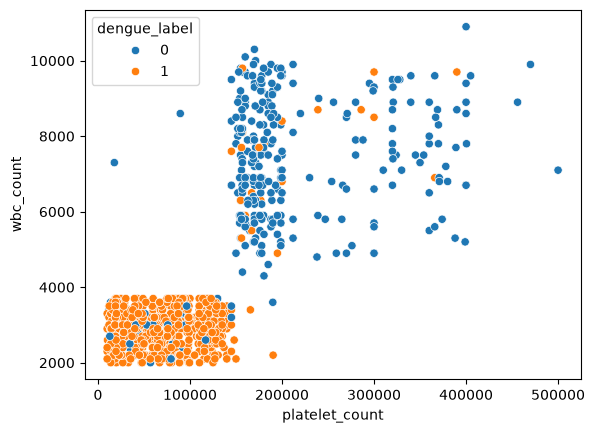

In [71]:
sns.scatterplot(data=df,x="platelet_count",y="wbc_count",hue="dengue_label")

The scatter plot provides a clearer view of the relationship between platelet count, white blood cell count (WBC), and dengue diagnosis.

A noticeable concentration of dengue-positive cases can be observed in the lower-left region of the chart, where both platelet counts and white blood cell counts tend to be lower. This clustering suggests that patients diagnosed with dengue often share similar clinical characteristics, particularly reduced levels of these blood indicators.

While the scatter plot does not establish causation, it supports the relationships previously identified in the correlation analysis and indicates that these variables may contain valuable predictive information for machine learning models.

The presence of distinct patterns between dengue-positive and dengue-negative patients suggests that platelet count and white blood cell count could play an important role in distinguishing between the two groups.

Having identified these potentially informative features, the next step is to prepare the dataset for machine learning by addressing missing values, transforming categorical variables, and creating a clean dataset suitable for model training and evaluation.

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder

Data quality is a critical component of any machine learning project. Missing values can negatively affect model performance and may introduce bias if not handled appropriately.

Before proceeding with model training, the dataset is examined for missing observations across all features. Understanding the extent of missing data allows us to select an appropriate preprocessing strategy while preserving as much information as possible.

The following analysis identifies the variables affected by missing values and guides the imputation process used during data preparation

In [89]:
le=LabelEncoder()
df["gender"] = le.fit_transform(df['gender'])

In [74]:
df.isnull().sum()

age                             0
gender                          0
hemoglobin_g_dl                 0
wbc_count                      24
differential_count              0
rbc_count                       0
platelet_count                 16
platelet_distribution_width    19
dengue_label                    0
dtype: int64

In [90]:
def fill_null_values(column_name):
    column_mean = df[column_name].mean()
    
    # Fill the missing values inline
    df[column_name] = df[column_name].fillna(column_mean)
    
    return df
df= fill_null_values("platelet_distribution_width")
df= fill_null_values("platelet_count")
df= fill_null_values("wbc_count")

In [76]:
df.isnull().sum()

age                            0
gender                         0
hemoglobin_g_dl                0
wbc_count                      0
differential_count             0
rbc_count                      0
platelet_count                 0
platelet_distribution_width    0
dengue_label                   0
dtype: int64

After identifying incomplete observations within the dataset, a preprocessing strategy is required to ensure compatibility with machine learning algorithms.

For this project, missing numerical values are replaced using mean imputation. This approach preserves all available records while providing a simple and reproducible baseline for model development.

With the dataset cleaned and prepared, the next phase focuses on developing a machine learning model capable of identifying patterns associated with dengue cases.

The dataset is divided into training and testing subsets using a stratified split to preserve the original class distribution. This ensures that model performance is evaluated on data that was not seen during training.

A Random Forest classifier is selected as the initial model due to its ability to capture non-linear relationships and interactions between clinical variables without extensive feature engineering.

The trained model will then be evaluated to determine how effectively it distinguishes between dengue-positive and dengue-negative patients.

In [91]:
X= df.drop("dengue_label",axis=1)
y= df["dengue_label"]


SPLIT_RATIO = 0.3
SEED = 42

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=SPLIT_RATIO, random_state=SEED
)

In [78]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [92]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",100000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is

In [85]:
y_pred_rf = rf.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_rf)
print(classification_report(y_val, y_pred_rf))


              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.91      0.94      0.92        51

    accuracy                           0.90        81
   macro avg       0.90      0.89      0.89        81
weighted avg       0.90      0.90      0.90        81



In [96]:
y_pred = model.predict(X_val)


print("\nClassification Report:")
print(classification_report(y_val, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.95      0.95      0.95        41

    accuracy                           0.93        57
   macro avg       0.91      0.91      0.91        57
weighted avg       0.93      0.93      0.93        57



The objective of this project was to explore whether clinical patient data could be used to identify patterns associated with dengue cases and to evaluate the effectiveness of machine learning models for dengue risk classification.

During the exploratory analysis, several clinical variables demonstrated meaningful relationships with the dengue label. In particular, platelet count and white blood cell count emerged as potentially important predictors, with dengue-positive cases showing a tendency to cluster around lower values of these indicators.

To evaluate predictive performance, both Logistic Regression and Random Forest classifiers were trained and tested on the dataset. While Logistic Regression achieved strong results with an overall accuracy of 89%, the Random Forest model slightly outperformed it, achieving an accuracy of 90% and higher recall for dengue-positive cases.

The superior performance of the Random Forest model suggests that the relationships within the dataset are not entirely linear and that interactions between clinical variables may contribute to more accurate predictions. This highlights the advantage of ensemble tree-based methods when working with complex healthcare datasets.

Overall, the results demonstrate that machine learning models can successfully identify patterns associated with dengue cases using clinical data. Although this project is intended for educational and analytical purposes rather than clinical diagnosis, it showcases the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model development, and performance evaluation.

Future improvements could include hyperparameter tuning, additional feature engineering, model explainability techniques such as feature importance analysis, and the evaluation of more advanced classification algorithms.
